DataFrame 'df' successfully loaded from data/Assignment_8_newtons_law_time_distance_data_SLR.csv.
--------------------------------------------------
Target variable (y): y
Feature variables (x): ['x']
First x variable for plotting: x
--------------------------------------------------
Data Split: Train size = 70, Test size = 31


################ SCKIT-LEARN LINEAR REGRESSION ################

--- SKLEARN: Train Set Results ---
--- Sklearn Metrics ---
R2: 0.9232
MAE: 33.0569
RMSE: 38.6720
--------------------


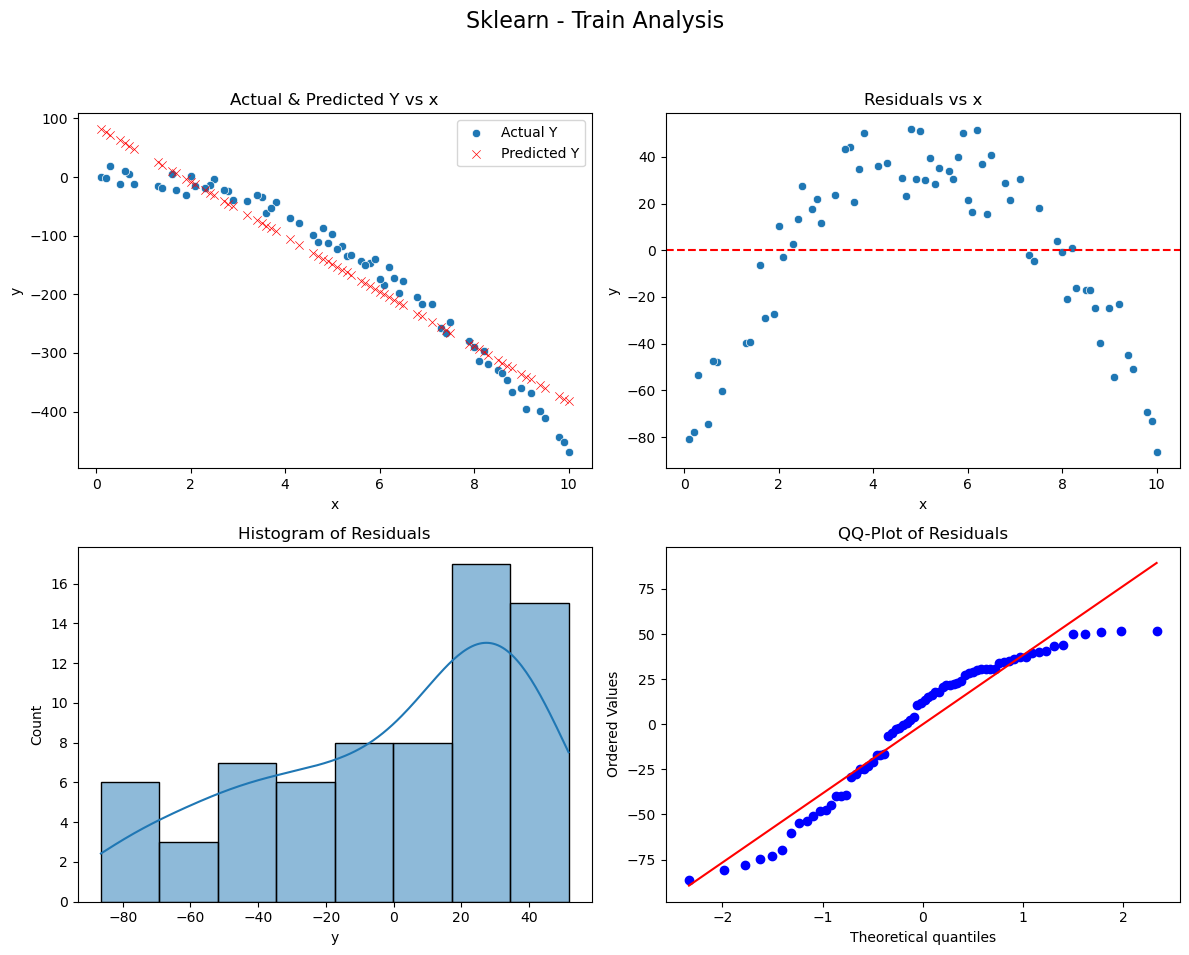


--- SKLEARN: Test Set Results ---
--- Sklearn Metrics ---
R2: 0.9308
MAE: 31.7933
RMSE: 38.2726
--------------------


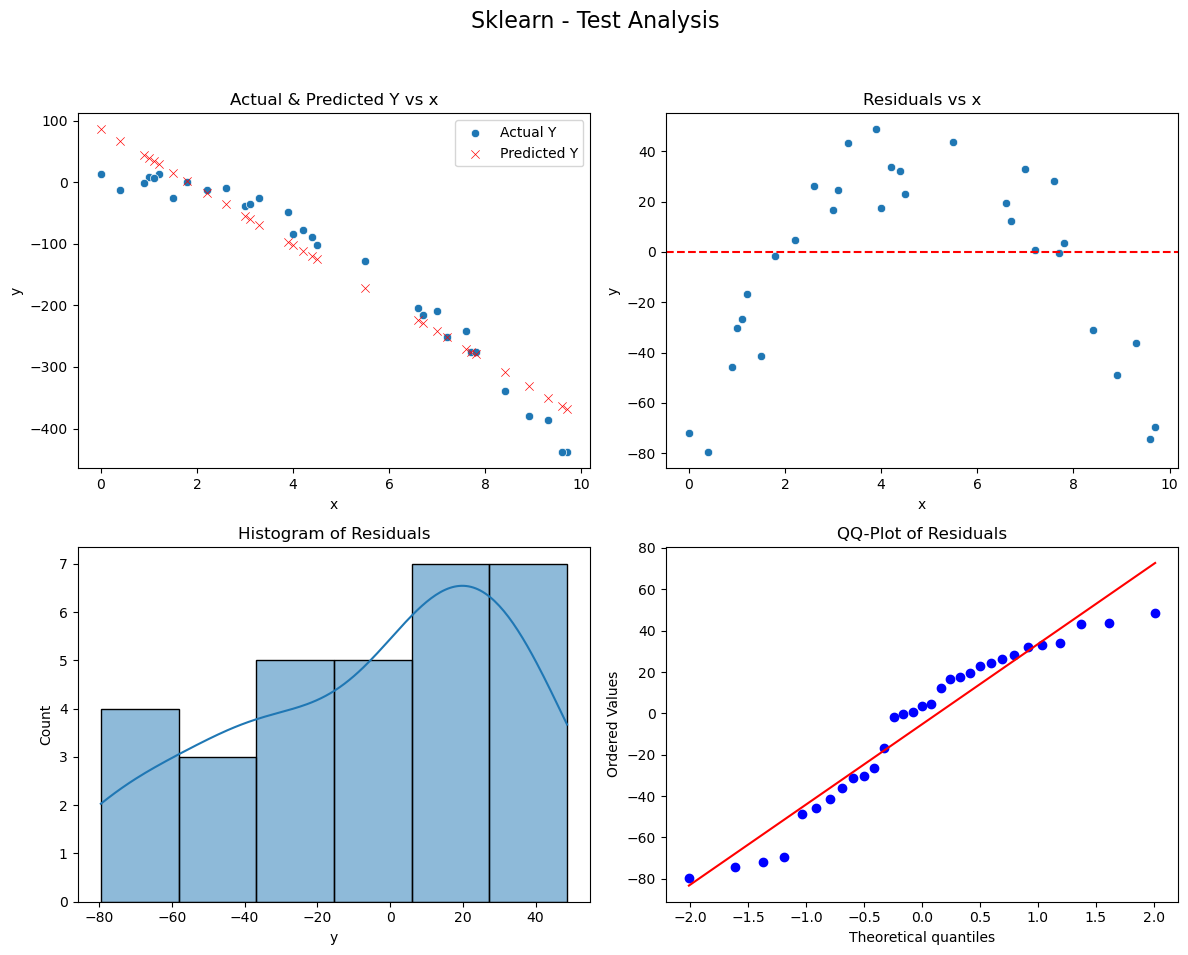



################ STATSMODELS OLS REGRESSION ################
Statsmodels OLS Regression Summary (Standard):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     817.9
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.24e-39
Time:                        04:53:18   Log-Likelihood:                -355.18
No. Observations:                  70   AIC:                             714.4
Df Residuals:                      68   BIC:                             718.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

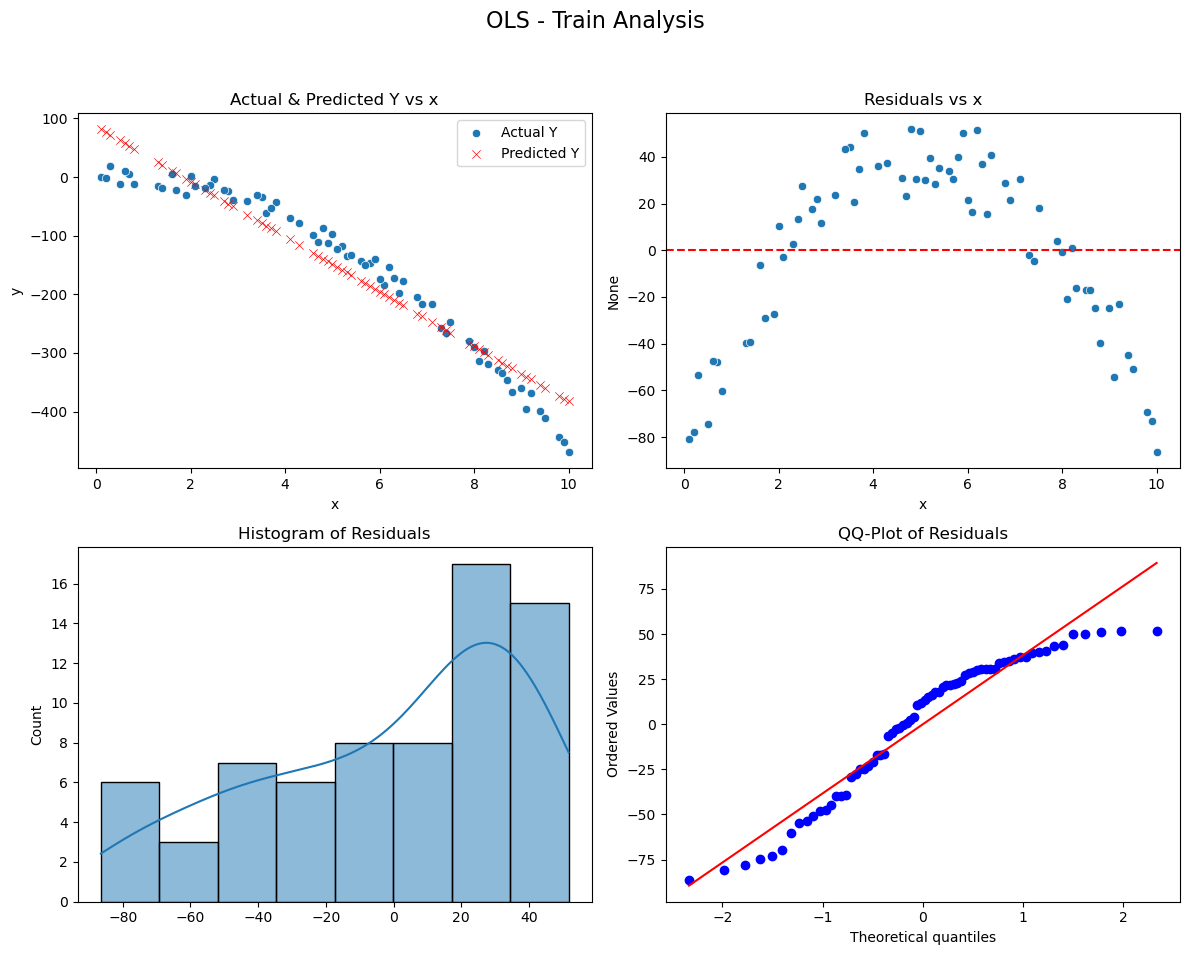


--- OLS: Test Set Results ---
--- OLS Metrics ---
R2: 0.9308
MAE: 31.7933
RMSE: 38.2726
--------------------


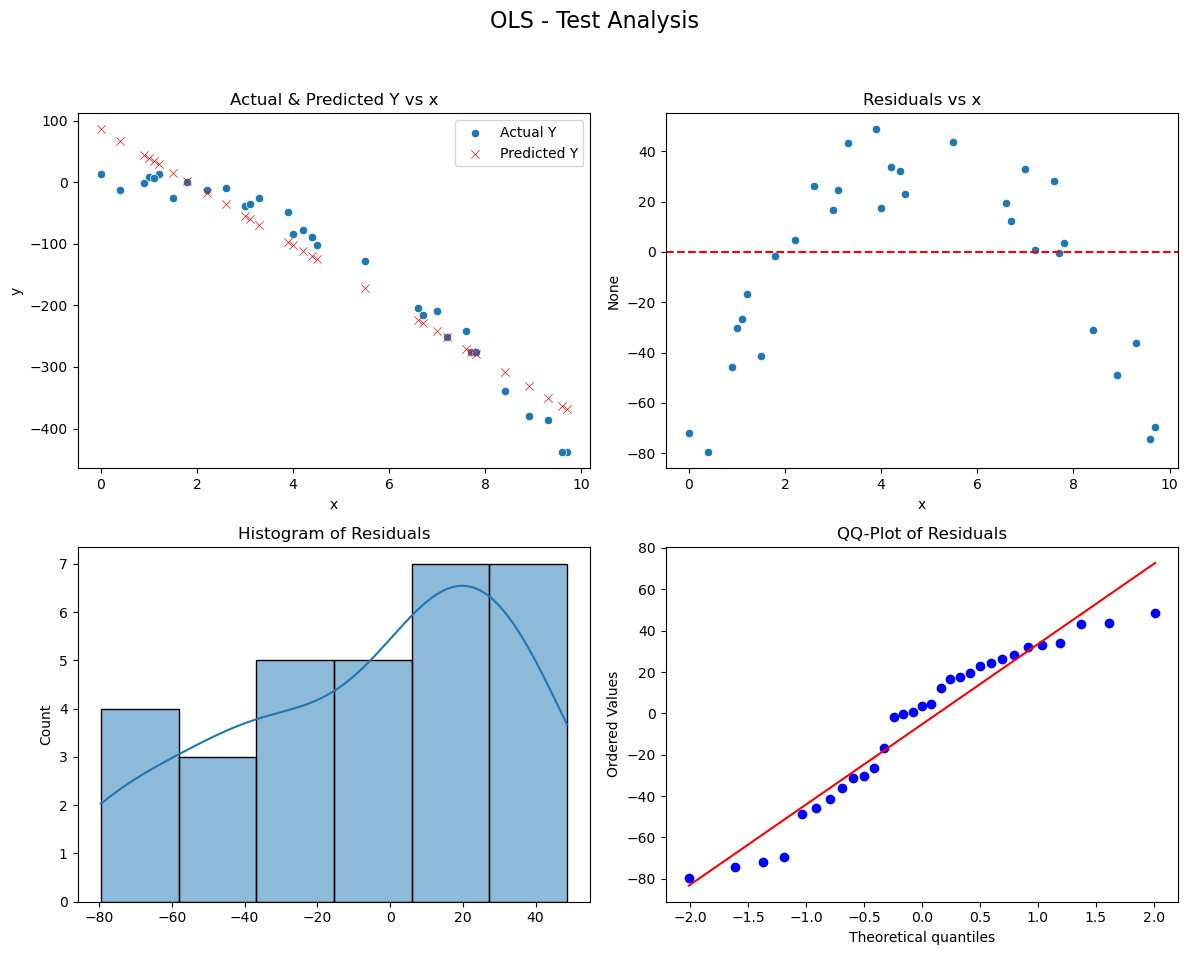

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import sys
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# 1. Create dataframe df from the file
ipfile = 'data/Assignment_8_newtons_law_time_distance_data_SLR.csv'

try:
    df = pd.read_csv(ipfile)
    print(f"DataFrame 'df' successfully loaded from {ipfile}.")
except FileNotFoundError:
    print(f"FATAL ERROR: The file '{ipfile}' was not found.")
    print("Terminating program...")
    sys.exit(1)
except Exception as e:
    print(f"FATAL ERROR: An unexpected error occurred: {e}")
    sys.exit(1)

# Find 'y' and 'x' columns
if 'y' in df.columns:
    Y_COL = 'y'
    X_COLS = [col for col in df.columns if col.startswith('x') or col not in [Y_COL]]
else:
    print("Warning: 'y' column not found. Assuming the first column is 'y'.")
    Y_COL = df.columns[0]
    X_COLS = df.columns[1:].tolist()

FIRST_X_VAR = X_COLS[0] if X_COLS else None

print("-" * 50)
print(f"Target variable (y): {Y_COL}")
print(f"Feature variables (x): {X_COLS}")
print(f"First x variable for plotting: {FIRST_X_VAR}")
print("-" * 50)

def evaluate_and_plot(model_name, y_true, y_pred, X_data, residuals, X_var_for_plot):
    """Calculates metrics and generates the required plots."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"--- {model_name} Metrics ---")
    print(f"R2: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print("-" * 20)

    if X_var_for_plot is None:
        return

    # Data handling for plotting
    if isinstance(X_data, (pd.DataFrame, pd.Series)):
        X_plot_data = X_data[X_var_for_plot]
    elif isinstance(X_data, np.ndarray) and len(X_data.shape) > 1:
        X_plot_data = X_data[:, 0]
    else:
        X_plot_data = X_data 

    data_type = "Test" if len(y_true) * 2 < len(df) else "Train" if len(y_true) < len(df) else "Full Data"
    
    fig = plt.figure(figsize=(12, 10)) 
    fig.suptitle(f"{model_name} - {data_type} Analysis", fontsize=16)

    ax1 = fig.add_subplot(2, 2, 1) 
    sns.scatterplot(x=X_plot_data, y=y_true, label='Actual Y', ax=ax1)
    sns.scatterplot(x=X_plot_data, y=y_pred, label='Predicted Y', ax=ax1, marker='x', color='red')
    ax1.set_title(f'Actual & Predicted Y vs {X_var_for_plot}')
    ax1.legend()
    
    ax2 = fig.add_subplot(2, 2, 2) 
    sns.scatterplot(x=X_plot_data, y=residuals, ax=ax2)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_title(f'Residuals vs {X_var_for_plot}')
    
    ax4 = fig.add_subplot(2, 2, 3)
    sns.histplot(residuals, kde=True, ax=ax4)
    ax4.set_title('Histogram of Residuals')
    
    ax5 = fig.add_subplot(2, 2, 4)
    stats.probplot(residuals, dist="norm", plot=ax5)
    ax5.set_title('QQ-Plot of Residuals')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def sklearn_regression(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def OLS_regression(X_train, y_train):
    X_train_sm = sm.add_constant(X_train)
    model = sm.OLS(y_train, X_train_sm).fit()
    print("=" * 70)
    print("Statsmodels OLS Regression Summary (Standard):")
    print(model.summary())
    print("=" * 70)
    return model

def do_regression_analysis(df, Y_COL, X_COLS, FIRST_X_VAR):
    if not X_COLS or not FIRST_X_VAR:
        return

    X = df[X_COLS]
    y = df[Y_COL]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    print(f"Data Split: Train size = {len(X_train)}, Test size = {len(X_test)}")
    
    # --- SKLEARN ANALYSIS ---
    print("\n\n################ SCKIT-LEARN LINEAR REGRESSION ################")
    sk_model = sklearn_regression(X_train, y_train)
    
    print("\n--- SKLEARN: Train Set Results ---")
    y_train_pred_sk = sk_model.predict(X_train)
    evaluate_and_plot("Sklearn", y_train, y_train_pred_sk, X_train, y_train - y_train_pred_sk, FIRST_X_VAR)
    
    print("\n--- SKLEARN: Test Set Results ---")
    y_test_pred_sk = sk_model.predict(X_test)
    evaluate_and_plot("Sklearn", y_test, y_test_pred_sk, X_test, y_test - y_test_pred_sk, FIRST_X_VAR)

    # --- STATSMODELS ANALYSIS ---
    print("\n\n################ STATSMODELS OLS REGRESSION ################")
    ols_model = OLS_regression(X_train, y_train)
    
    print("\n--- OLS: Train Set Results ---")
    X_train_sm = sm.add_constant(X_train) 
    y_train_pred_ols = ols_model.predict(X_train_sm)
    evaluate_and_plot("OLS", y_train, y_train_pred_ols, X_train, y_train - y_train_pred_ols, FIRST_X_VAR)
    
    print("\n--- OLS: Test Set Results ---")
    X_test_sm = sm.add_constant(X_test)
    y_test_pred_ols = ols_model.predict(X_test_sm)
    evaluate_and_plot("OLS", y_test, y_test_pred_ols, X_test, y_test - y_test_pred_ols, FIRST_X_VAR)

if __name__ == "__main__":
    if 'df' in locals():
        do_regression_analysis(df, Y_COL, X_COLS, FIRST_X_VAR)